### Import Library

In [1]:
import sqlite3 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

### Connect Database

In [3]:
conn = sqlite3.connect("chocolate_sales.db")

### Load CSV Files

In [4]:
sales = pd.read_csv("../Datasets/sales.csv")
calendar = pd.read_csv("../Datasets/calendar.csv")
customers = pd.read_csv("../Datasets/customers.csv")
products = pd.read_csv("../Datasets/products.csv")
stores = pd.read_csv("../Datasets/stores.csv")

In [5]:
sales.head(5)

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,profit
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,18.56
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,16.97
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,9.75
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,10.04
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,4.40


In [6]:
calendar.head(5)

,date,year,month,day,week,day_of_week
0,2023-01-01,2023,1,1,52,6
1,2023-01-02,2023,1,2,1,0
2,2023-01-03,2023,1,3,1,1
3,2023-01-04,2023,1,4,1,2
4,2023-01-05,2023,1,5,1,3


In [7]:
customers.head(5)

,customer_id,age,gender,loyalty_member,join_date
0,C000001,40,Male,1,2025-05-21
1,C000002,47,Male,0,2021-12-26
2,C000003,58,Female,1,2022-09-13
3,C000004,25,Female,0,2025-02-27
4,C000005,43,Male,0,2023-08-31


In [8]:
products.head(5)

,product_id,product_name,brand,category,cocoa_percent,weight_g
0,P0001,White Chocolate 80%,Mars,Truffle,80,120
1,P0002,Dark Chocolate 70%,Cadbury,Praline,70,100
2,P0003,Truffle Chocolate 70%,Hershey,Praline,70,120
3,P0004,Milk Chocolate 50%,Mars,Praline,50,80
4,P0005,White Chocolate 70%,Ferrero,White,70,50


In [9]:
stores.head(5)

,store_id,store_name,city,country,store_type
0,S001,Chocolate Store 1,New York,Canada,Retail
1,S002,Chocolate Store 2,Melbourne,Canada,Mall
2,S003,Chocolate Store 3,Berlin,France,Mall
3,S004,Chocolate Store 4,Paris,UK,Airport
4,S005,Chocolate Store 5,Sydney,USA,Online


### Insert into SQLITE

In [10]:
sales.to_sql('sales', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)
stores.to_sql('stores', conn, if_exists='replace', index=False)
calendar.to_sql('calendar', conn, if_exists='replace', index=False)
customers.to_sql('customers', conn, if_exists='replace', index=False)

print("Data has been successfully imported into the SQLite database.")

Data has been successfully imported into the SQLite database.


### Join Table (sales_master)

In [11]:
query_sales_master = """
SELECT 
    s.order_id,
    s.order_date,

    --Time
    cal.year,
    cal.month,
    cal.day,
    cal.week,
    cal.day_of_week,

    --Metrics
    s.quantity,
    s.unit_price,
    s.discount,
    s.revenue,
    s.cost,
    s.profit,

    --Product
    p.product_id,
    p.product_name,
    p.brand,
    p.category,
    p.cocoa_percent,
    p.weight_g,

    --Store 
    st.store_id,
    st.store_name,
    st.city,
    st.country,
    st.store_type,

    --Customer 
    c.customer_id,
    c.age,
    c.gender,
    c.loyalty_member,
    c.join_date
FROM sales s

LEFT JOIN products p 
    ON s.product_id = p.product_id

LEFT JOIN stores st 
    ON s.store_id = st.store_id

LEFT JOIN customers c 
    ON s.customer_id = c.customer_id

LEFT JOIN calendar cal
    ON s.order_date = cal.date
"""

In [12]:
df = pd.read_sql_query(query_sales_master, conn)

print("Data Berhasil Joined ke dalam Dataframe Master")
df.head(5)

Data Berhasil Joined ke dalam Dataframe Master


,order_id,order_date,year,month,day,week,day_of_week,quantity,unit_price,discount,revenue,cost,profit,product_id,product_name,brand,category,cocoa_percent,weight_g,store_id,store_name,city,country,store_type,customer_id,age,gender,loyalty_member,join_date
0,0RD00000001,2023-01-07,2023,1,7,1,5,5,14.43,0.15,61.33,42.77,18.56,P0080,Praline Chocolate 70%,Hershey,White,70.0,200.0,S093,Chocolate Store 93,Sydney,UK,Airport,C040749,44,Male,1,2021-11-17
1,0RD00000002,2023-10-22,2023,10,22,42,6,3,12.01,0.00,36.03,19.06,16.97,P0173,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,S065,Chocolate Store 65,New York,Australia,Retail,C020161,63,Female,1,2023-07-03
2,0RD00000003,2023-05-07,2023,5,7,18,6,2,10.02,0.00,20.04,10.29,9.75,P0115,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,S078,Chocolate Store 78,London,UK,Airport,C048069,35,Male,1,2023-10-09
3,0RD00000004,2024-06-23,2024,6,23,25,6,2,14.66,0.10,26.39,16.35,10.04,P0186,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,S088,Chocolate Store 88,Toronto,USA,Retail,C047901,37,Female,1,2023-05-30
4,0RD00000005,2024-09-24,2024,9,24,39,1,1,12.34,0.00,12.34,7.94,4.40,P0197,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,S054,Chocolate Store 54,London,Canada,Online,C033950,57,Female,0,2021-08-20


### Initial Data Analysis (IDA)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   order_id        1000000 non-null  object 
 1   order_date      1000000 non-null  object 
 2   year            1000000 non-null  int64  
 3   month           1000000 non-null  int64  
 4   day             1000000 non-null  int64  
 5   week            1000000 non-null  int64  
 6   day_of_week     1000000 non-null  int64  
 7   quantity        1000000 non-null  int64  
 8   unit_price      1000000 non-null  float64
 9   discount        1000000 non-null  float64
 10  revenue         1000000 non-null  float64
 11  cost            1000000 non-null  float64
 12  profit          1000000 non-null  float64
 13  product_id      990236 non-null   object 
 14  product_name    990236 non-null   object 
 15  brand           990236 non-null   object 
 16  category        990236 non-null   obj

### Check Missing Values

In [14]:
missing = df.isnull().sum()
persen = (missing / len(df)*100).round(2)
missing_data = pd.DataFrame({'Missing Values' : missing, 'Percentage (%)' : persen})
print("Missing Values in the DataFrame:")
print(missing_data)

Missing Values in the DataFrame:
                Missing Values  Percentage (%)
order_id                     0            0.00
order_date                   0            0.00
year                         0            0.00
month                        0            0.00
day                          0            0.00
week                         0            0.00
day_of_week                  0            0.00
quantity                     0            0.00
unit_price                   0            0.00
discount                     0            0.00
revenue                      0            0.00
cost                         0            0.00
profit                       0            0.00
product_id                9764            0.98
product_name              9764            0.98
brand                     9764            0.98
category                  9764            0.98
cocoa_percent             9764            0.98
weight_g                  9764            0.98
store_id                   

### Preprocessing

In [15]:
df[df['product_name'].isnull()][['product_id']].head()

,product_id
193,None
390,None
433,None
714,None
748,None


In [16]:
df[df['product_id'].isnull()].shape

(9764, 29)

In [17]:
df['product_id'] = df['product_id'].fillna('UNKNOWN')
df['product_name'] = df['product_name'].fillna('Unknown Product')
df['category'] = df['category'].fillna('Unknown Category')
df['brand'] = df['brand'].fillna('Unknown Brand')

In [18]:
df['cocoa_percent'] = df['cocoa_percent'].fillna(0)
df['weight_g'] = df['weight_g'].fillna(0)

In [19]:
df['customer_type'] = df['loyalty_member'].map({
    1 : 'Loyalty Member',
    0: 'Reguler Customer'
})

In [20]:
df.drop(columns=['loyalty_member'], inplace=True)

In [21]:
df['customer_type'].head(10)

0      Loyalty Member
1      Loyalty Member
2      Loyalty Member
3      Loyalty Member
4    Reguler Customer
5    Reguler Customer
6    Reguler Customer
7    Reguler Customer
8      Loyalty Member
9    Reguler Customer
Name: customer_type, dtype: object

In [22]:
float_cols = [
    'unit_price',
    'discount',
    'revenue',
    'cost',
    'profit'
]

for col in float_cols:
    df[col] = df[col].astype(float).round(2)

### EDA

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 29 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   order_id       1000000 non-null  object 
 1   order_date     1000000 non-null  object 
 2   year           1000000 non-null  int64  
 3   month          1000000 non-null  int64  
 4   day            1000000 non-null  int64  
 5   week           1000000 non-null  int64  
 6   day_of_week    1000000 non-null  int64  
 7   quantity       1000000 non-null  int64  
 8   unit_price     1000000 non-null  float64
 9   discount       1000000 non-null  float64
 10  revenue        1000000 non-null  float64
 11  cost           1000000 non-null  float64
 12  profit         1000000 non-null  float64
 13  product_id     1000000 non-null  object 
 14  product_name   1000000 non-null  object 
 15  brand          1000000 non-null  object 
 16  category       1000000 non-null  object 
 17  cocoa_per

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
(df['revenue']<0).sum()
(df['profit']<0).sum()
(df['discount']<0).sum()
(df['weight_g']<0).sum()

np.int64(0)

In [26]:
df.describe()

,year,month,day,week,day_of_week,quantity,unit_price,discount,revenue,cost,profit,cocoa_percent,weight_g,age
count,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2023.50043,6.516521,15.726768,26.444866,2.999049,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565,68.472970,106.382440,44.044222
std,0.50000,3.449879,8.806623,15.069053,2.003559,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760,16.038277,51.565036,15.330664
min,2023.00000,1.000000,1.000000,1.000000,0.000000,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,0.000000,0.000000,18.000000
25%,2023.00000,4.000000,8.000000,13.000000,1.000000,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,50.000000,80.000000,31.000000
50%,2024.00000,7.000000,16.000000,26.000000,3.000000,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000,70.000000,100.000000,44.000000
75%,2024.00000,10.000000,23.000000,39.000000,5.000000,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000,80.000000,120.000000,57.000000
max,2024.00000,12.000000,31.000000,52.000000,6.000000,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,90.000000,200.000000,70.000000


In [27]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df[['product_name', 'brand', 'category', 'store_name', 'city', 'country', 'store_type','gender', 'customer_type']]

### Check Consistency Format

In [28]:
for col in cat_cols:
    print(f"Unique values in {col}:")
    print(df[col].value_counts())
    print('---'*40)

Unique values in product_name:
product_name
Dark Chocolate 50%       69625
Truffle Chocolate 80%    64490
Milk Chocolate 70%       54127
Praline Chocolate 50%    54056
Dark Chocolate 60%       49813
White Chocolate 50%      49699
White Chocolate 90%      44709
Truffle Chocolate 90%    44693
White Chocolate 80%      44455
Praline Chocolate 70%    44377
Truffle Chocolate 50%    40004
Dark Chocolate 90%       39763
Dark Chocolate 70%       39708
Milk Chocolate 50%       39672
White Chocolate 70%      39327
Truffle Chocolate 70%    34853
Praline Chocolate 90%    34522
Milk Chocolate 60%       34480
Milk Chocolate 90%       29690
Milk Chocolate 80%       29623
White Chocolate 60%      29534
Dark Chocolate 80%       24798
Praline Chocolate 80%    19841
Praline Chocolate 60%    19566
Truffle Chocolate 60%    14811
Unknown Product           9764
Name: count, dtype: int64
------------------------------------------------------------------------------------------------------------------------
Uni

### Check Outliers

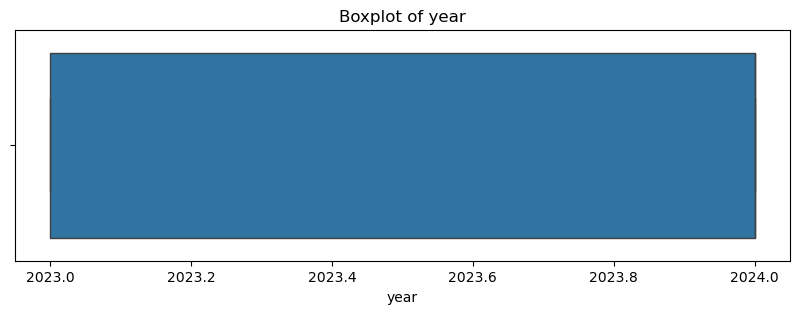

------------------------------------------------------------------------------------------------------------------------


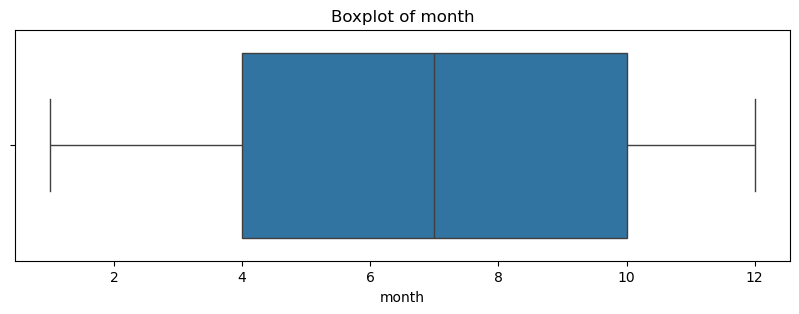

------------------------------------------------------------------------------------------------------------------------


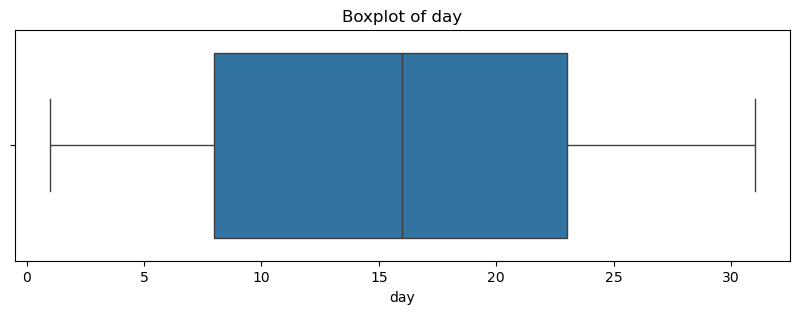

------------------------------------------------------------------------------------------------------------------------


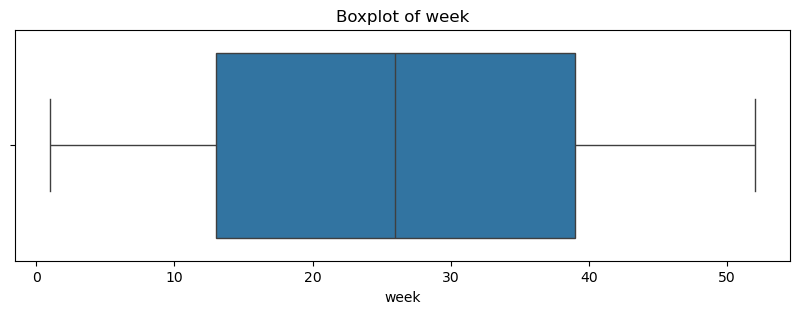

------------------------------------------------------------------------------------------------------------------------


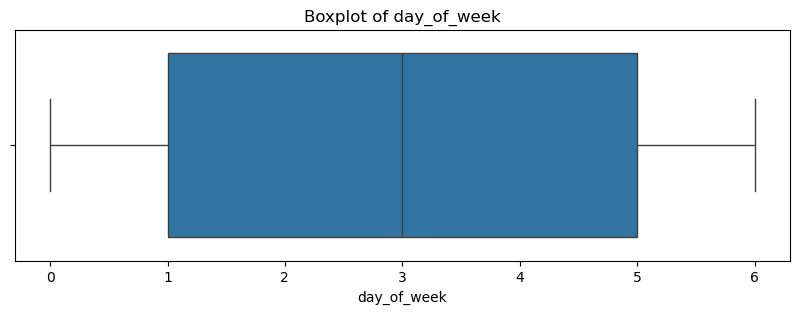

------------------------------------------------------------------------------------------------------------------------


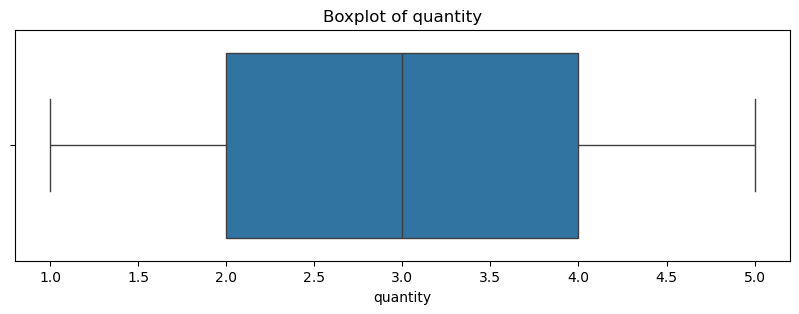

------------------------------------------------------------------------------------------------------------------------


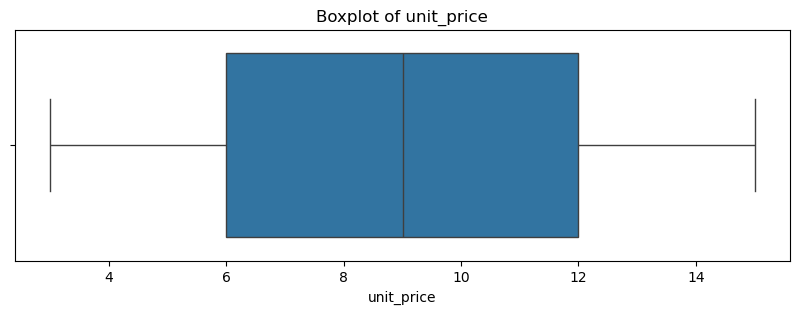

------------------------------------------------------------------------------------------------------------------------


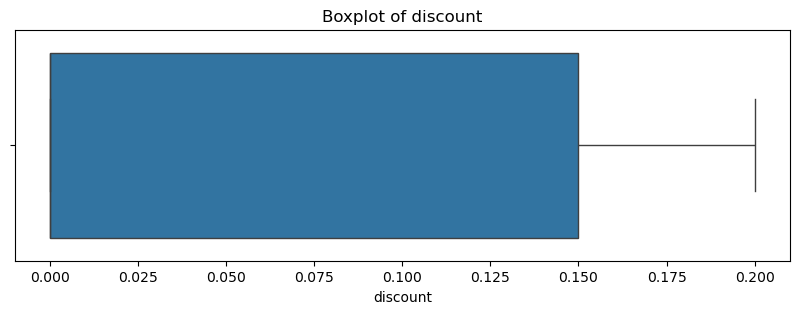

------------------------------------------------------------------------------------------------------------------------


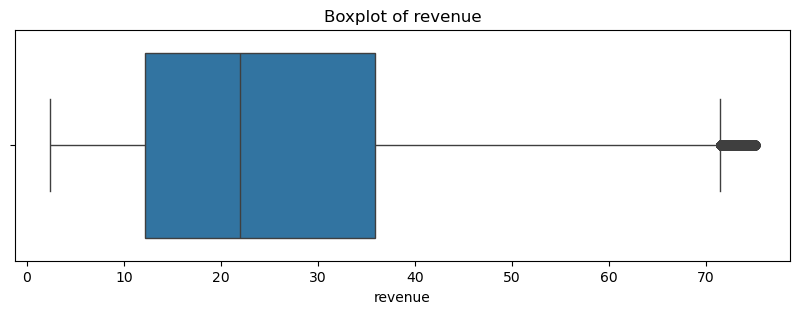

------------------------------------------------------------------------------------------------------------------------


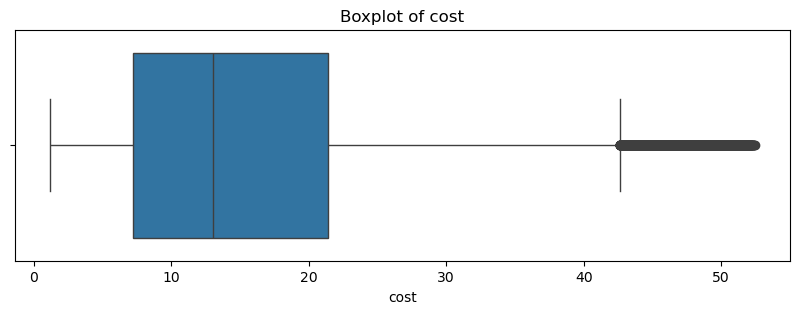

------------------------------------------------------------------------------------------------------------------------


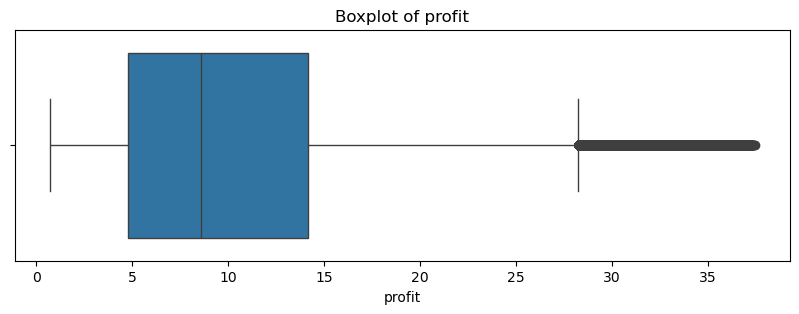

------------------------------------------------------------------------------------------------------------------------


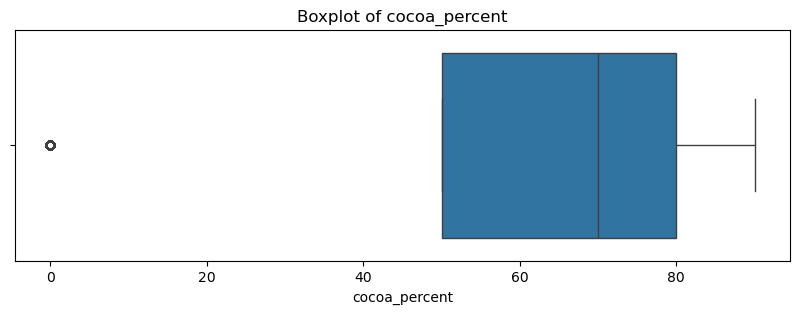

------------------------------------------------------------------------------------------------------------------------


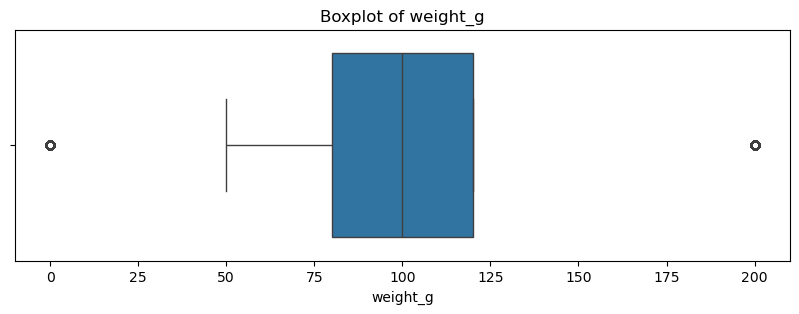

------------------------------------------------------------------------------------------------------------------------


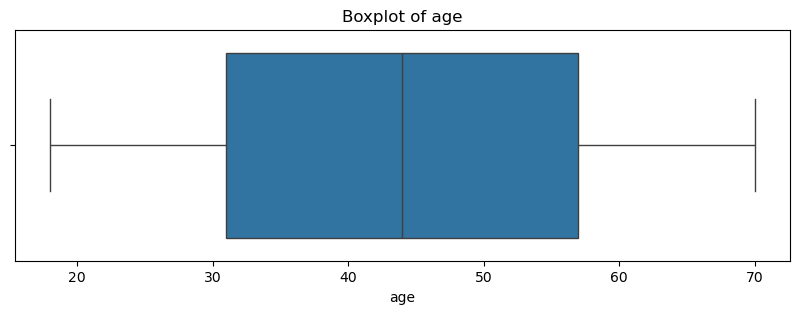

------------------------------------------------------------------------------------------------------------------------


In [29]:
for col in num_cols:
    plt.figure(figsize=(10,3))
    sns.boxplot(df[col],orient='h')
    plt.title(f'Boxplot of {col}')
    plt.show()
    print('---'*40)

<Axes: >

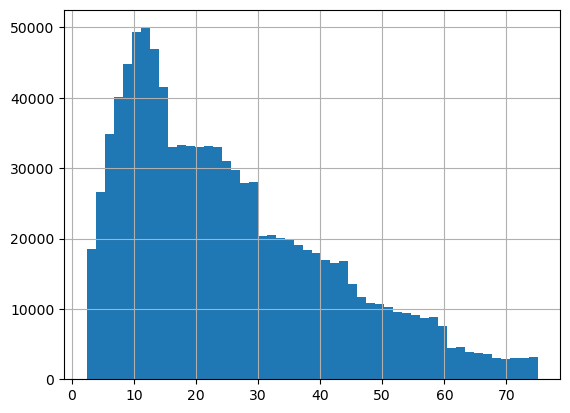

In [30]:
df['revenue'].hist(bins=50)

<Axes: xlabel='category'>

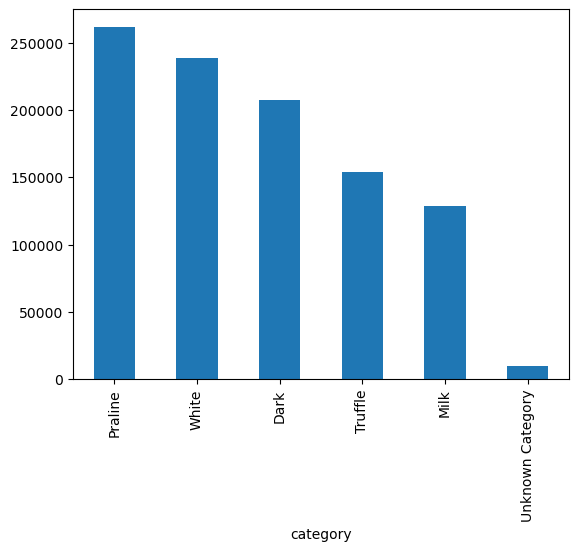

In [31]:
df['category'].value_counts().plot(kind='bar')

### Feature Engineering

In [32]:
bins = [18, 25, 35, 45, 55, 65, 80]

labels = [
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55-64',
    '65++'
]

df['age_group'] = pd.cut(df['age'],bins=bins, labels=labels,right=False)

In [33]:
# Make profit margin column
df['profit_margin'] = df['profit'] / df['revenue']
df['profit_margin_pct'] = ((df['profit'] / df['revenue'])*100).round(2)

df[['profit_margin_pct', 'profit_margin']].head()


,profit_margin_pct,profit_margin
0,30.26,0.302625
1,47.10,0.470996
2,48.65,0.486527
3,38.04,0.380447
4,35.66,0.356564


In [34]:
# Make Quarter Column
df['order_date'] = pd.to_datetime(df['order_date'])

df['quarter'] = df['order_date'].dt.quarter

### Post-Feature EDA

In [35]:
df['age_group'].value_counts()

age_group
55-64    190541
45-54    188728
35-44    188556
25-34    184663
18-24    133960
65++     113552
Name: count, dtype: int64

In [36]:
df.groupby('age_group')['profit'].sum().sort_values(ascending=False)

C:\Users\Doni\AppData\Local\Temp\ipykernel_20936\3348295532.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['profit'].sum().sort_values(ascending=False)


age_group
55-64    1940747.66
35-44    1923818.86
45-54    1923104.40
25-34    1883919.95
18-24    1364153.94
65++     1158819.82
Name: profit, dtype: float64

In [37]:
df.groupby('quarter')['revenue'].sum().sort_values(ascending=False)

quarter
3    6446539.79
4    6383411.10
2    6328199.69
1    6327978.28
Name: revenue, dtype: float64

In [38]:
pd.crosstab(df['age_group'],df['customer_type'])

customer_type,Loyalty Member,Reguler Customer
age_group,,
18-24,67009,66951
25-34,93004,91659
35-44,94262,94294
45-54,94603,94125
55-64,95824,94717
65++,57196,56356


### Import to CSV

In [39]:
df.to_csv('chocolate_sales_master.csv', index=False)

In [40]:
df.head()

,order_id,order_date,year,month,day,week,day_of_week,quantity,unit_price,discount,revenue,cost,profit,product_id,product_name,brand,category,cocoa_percent,weight_g,store_id,store_name,city,country,store_type,customer_id,age,gender,join_date,customer_type,age_group,profit_margin,profit_margin_pct,quarter
0,0RD00000001,2023-01-07,2023,1,7,1,5,5,14.43,0.15,61.33,42.77,18.56,P0080,Praline Chocolate 70%,Hershey,White,70.0,200.0,S093,Chocolate Store 93,Sydney,UK,Airport,C040749,44,Male,2021-11-17,Loyalty Member,35-44,0.302625,30.26,1
1,0RD00000002,2023-10-22,2023,10,22,42,6,3,12.01,0.00,36.03,19.06,16.97,P0173,Dark Chocolate 60%,Lindt,Praline,60.0,50.0,S065,Chocolate Store 65,New York,Australia,Retail,C020161,63,Female,2023-07-03,Loyalty Member,55-64,0.470996,47.10,4
2,0RD00000003,2023-05-07,2023,5,7,18,6,2,10.02,0.00,20.04,10.29,9.75,P0115,Milk Chocolate 90%,Hershey,Milk,90.0,50.0,S078,Chocolate Store 78,London,UK,Airport,C048069,35,Male,2023-10-09,Loyalty Member,35-44,0.486527,48.65,2
3,0RD00000004,2024-06-23,2024,6,23,25,6,2,14.66,0.10,26.39,16.35,10.04,P0186,Dark Chocolate 60%,Godiva,Praline,60.0,50.0,S088,Chocolate Store 88,Toronto,USA,Retail,C047901,37,Female,2023-05-30,Loyalty Member,35-44,0.380447,38.04,2
4,0RD00000005,2024-09-24,2024,9,24,39,1,1,12.34,0.00,12.34,7.94,4.40,P0197,Truffle Chocolate 90%,Hershey,Truffle,90.0,120.0,S054,Chocolate Store 54,London,Canada,Online,C033950,57,Female,2021-08-20,Reguler Customer,55-64,0.356564,35.66,3
